In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/arijitmohanta/01-data-loading-eda/__results__.html
/kaggle/input/notebooks/arijitmohanta/01-data-loading-eda/__notebook__.ipynb
/kaggle/input/notebooks/arijitmohanta/01-data-loading-eda/__output__.json
/kaggle/input/notebooks/arijitmohanta/01-data-loading-eda/wm811k_labeled.pkl
/kaggle/input/notebooks/arijitmohanta/01-data-loading-eda/custom.css
/kaggle/input/notebooks/arijitmohanta/01-data-loading-eda/__results___files/__results___5_0.png
/kaggle/input/notebooks/arijitmohanta/01-data-loading-eda/__results___files/__results___6_0.png


In [2]:
# ============================================================
# STAGE 2.1 — LOADING THE CLEAN CHECKPOINT
# Reloading the labeled working set saved at the end of Stage 1
# ============================================================

# Load the Stage 1 checkpoint (the cleaned, labeled wafers) rather than the raw
# LSWMD.pkl — so the expensive unwrap/filter step never has to run again.
work = pd.read_pickle('/kaggle/input/notebooks/arijitmohanta/01-data-loading-eda/wm811k_labeled.pkl')

# --- Verify the load matches the Stage 1 output ---
# Expected: ~172,950 rows and the 6 columns saved earlier
# (waferMap, dieSize, lotName, waferIndex, label, split).
print("Shape:", work.shape)
print()
print("Columns:", list(work.columns))
print()

# These counts should match the Stage 1 numbers exactly (same ~989:1 imbalance). If they differ, the wrong file was loaded.
print("Class counts:")
print(work['label'].value_counts())

Shape: (172950, 6)

Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'label', 'split']

Class counts:
label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


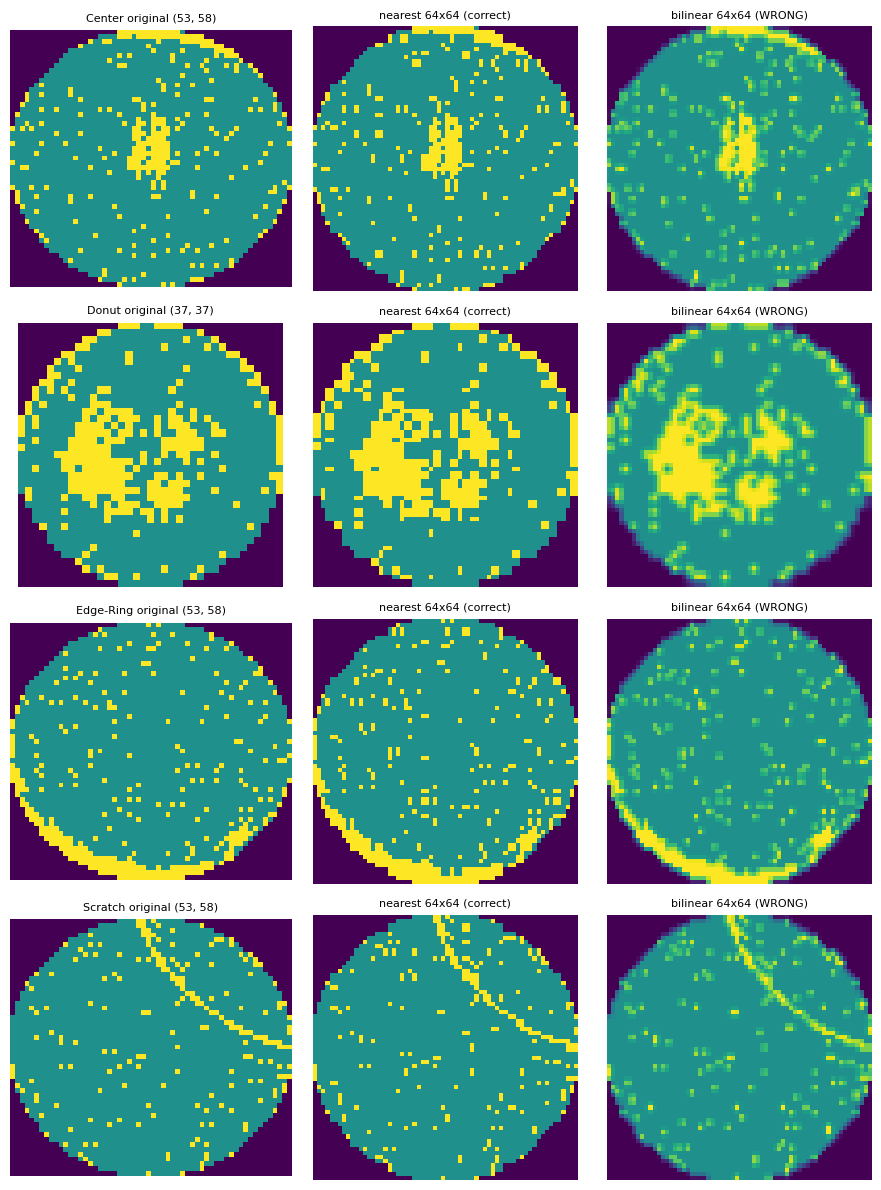

Original unique values: [0 1 2]
Nearest  unique values: [0 1 2]
Bilinear unique values (first 12): [0.         0.00915527 0.0111084  0.01477051 0.01831055 0.0222168
 0.02954102 0.04467773 0.04528809 0.046875   0.0579834  0.05895996]


In [3]:
# ============================================================
# STAGE 2.2 — RESIZE SANITY CHECK (nearest vs bilinear)
# Verifying HOW to resize on 4 example maps before batching 172,950.
# Wafer pixels are CATEGORICAL (0=outside, 1=pass, 2=fail), so any
# interpolation that averages neighbours invents states that don't exist.
# ============================================================
import matplotlib.pyplot as plt          # plotting library, to display wafer maps as images
from skimage.transform import resize      # resize function that lets us choose the interpolation method

# We test the resize on a handful of maps before running it across the whole dataset
# If the method is wrong, we want to catch it on 4 examples, not after transforming 172,950.
# We pick four patterns that look very different from each other, so any damage is easy to spot by eye.
sample_classes = ['Center', 'Donut', 'Edge-Ring', 'Scratch']  # four visually distinct patterns
examples = []                                                 # will hold (label, map array) pairs
for cls in sample_classes:                                    # loop over each chosen pattern
    one_map = work[work['label'] == cls].iloc[0]['waferMap']  # first row of that class -> its waferMap array
    examples.append((cls, one_map))                           # store the (label, array) pair for plotting

# Now show each example three ways side by side: 
#                  the untouched original,
#                  a 64x64 resize done correctly (nearest), and
#                  one done wrongly (bilinear).
# Laying them in one row per map makes the difference between the two methods obvious.
# The resize arguments control the method: 
#                  order=0 is nearest (copies the closest pixel),
#                  order=1 is bilinear (averages neighbours);
# preserve_range keeps the {0,1,2} values instead of rescaling to [0,1], and
# anti_aliasing adds smoothing that must stay off for categorical data.
fig, axes = plt.subplots(len(examples), 3, figsize=(9, 12))   # 4 rows x 3 cols of subplots
for r, (cls, wmap) in enumerate(examples):                    # r = row index; unpack label + array
    # Col 0 — original, untouched (reference)
    axes[r, 0].imshow(wmap, cmap='viridis', interpolation='nearest')  # raw map; 'nearest' = no DISPLAY smoothing
    axes[r, 0].set_title(f"{cls} original {wmap.shape}", fontsize=8)   # class name + true pixel size
    axes[r, 0].axis('off')                                            # hide meaningless pixel-index ticks
    # Col 1 — 64x64 via NEAREST-NEIGHBOUR (the correct method)
    near = resize(wmap, (64, 64),          # target shape (rows, cols) — numpy order, not (width, height)
                  order=0,                 # order=0 = nearest neighbour: copy closest pixel, never blend
                  preserve_range=True,     # keep the {0,1,2} values; don't rescale to [0,1]
                  anti_aliasing=False       # no smoothing — smoothing would create fractional values
                  ).astype(np.uint8)       # cast to small unsigned int: clean categories + low memory
    axes[r, 1].imshow(near, cmap='viridis', interpolation='nearest')
    axes[r, 1].set_title("nearest 64x64 (correct)", fontsize=8)
    axes[r, 1].axis('off')
    # Col 2 — 64x64 via BILINEAR (deliberately WRONG, to see the damage)
    bilin = resize(wmap, (64, 64),         # same target size
                   order=1,                # order=1 = bilinear: averages neighbours -> fractional values
                   preserve_range=True,
                   anti_aliasing=True)      # extra smoothing that compounds the averaging problem
    axes[r, 2].imshow(bilin, cmap='viridis', interpolation='nearest')
    axes[r, 2].set_title("bilinear 64x64 (WRONG)", fontsize=8)
    axes[r, 2].axis('off')
plt.tight_layout()                          # tidy spacing between subplots
plt.show()                                  # render the figure

# We print the distinct pixel values produced by each method.
# Nearest should still contain only {0,1,2};
# bilinear will contain a spread of fractions, each of which corresponds to no real die state.
demo = examples[0][1]                                                    # the Center example's raw array
print("Original unique values:", np.unique(demo))                       # expect exactly [0 1 2]
near_demo  = resize(demo, (64,64), order=0, preserve_range=True, anti_aliasing=False)
bilin_demo = resize(demo, (64,64), order=1, preserve_range=True, anti_aliasing=True)
print("Nearest  unique values:", np.unique(near_demo))                  # still [0 1 2] — categories preserved
print("Bilinear unique values (first 12):", np.unique(bilin_demo)[:12]) # a spray of meaningless fractions

In [4]:
# ============================================================
# STAGE 2.3 — BATCH RESIZE ALL MAPS -> ONE (N, 64, 64) TENSOR
# Applies the verified nearest-neighbour resize to every wafer and stacks the results into a single array the CNN can consume.
# Labels are saved in matching row order; alignment is asserted.
# ============================================================
import time                              # to time the loop, since it touches all 172,950 rows

# We resize every map to the same 64x64 grid and collect them in a list, then
# stack that list into one solid 3D array at the end. 
# Building a list first and stacking once is far faster than growing an array row by row.

IMG_SIZE = 64                            # target side length; one knob controls the whole pipeline

maps_resized = []                        # will collect one 64x64 array per wafer
labels       = []                        # collect labels IN THE SAME ORDER as maps_resized

start = time.time()                      # note the start time for a duration readout
for i, row in enumerate(work.itertuples(index=False)):   # itertuples = fast row iteration
    m = resize(row.waferMap, (IMG_SIZE, IMG_SIZE),       # the verified-correct resize call
               order=0,                                  # nearest neighbour
               preserve_range=True,                      # keep {0,1,2}
               anti_aliasing=False).astype(np.uint8)     # categorical -> small int
    maps_resized.append(m)               # append the resized map
    labels.append(row.label)             # append its label at the SAME position
    if (i + 1) % 20000 == 0:             # every 20k rows, show we're alive
        print(f"  {i+1:,} / {len(work):,} done")

# Stack the list of 2D arrays into one 3D array of shape (N, 64, 64).
# np.stack adds a new leading axis, giving us the "cube" of wafer images.
X_img  = np.stack(maps_resized).astype(np.uint8)   # the image tensor
y      = np.array(labels)                           # labels as a plain array, same order

print(f"\nDone in {time.time() - start:.0f}s")
print("X_img shape:", X_img.shape)      # expect (172950, 64, 64)
print("y shape:    ", y.shape)          # expect (172950,)
print("X_img dtype:", X_img.dtype)      # expect uint8
print("Memory:     ", f"{X_img.nbytes / 1024**2:.0f} MB")   # ~675 MB at uint8

# ALIGNMENT CHECK — the non-negotiable one. 
# If image count and label count ever disagree, every downstream metric is meaningless, so stop hard here.
assert X_img.shape[0] == y.shape[0], "Image/label count mismatch!"
print("\nAlignment OK — image count matches label count.")

  20,000 / 172,950 done
  40,000 / 172,950 done
  60,000 / 172,950 done
  80,000 / 172,950 done
  100,000 / 172,950 done
  120,000 / 172,950 done
  140,000 / 172,950 done
  160,000 / 172,950 done

Done in 18s
X_img shape: (172950, 64, 64)
y shape:     (172950,)
X_img dtype: uint8
Memory:      676 MB

Alignment OK — image count matches label count.


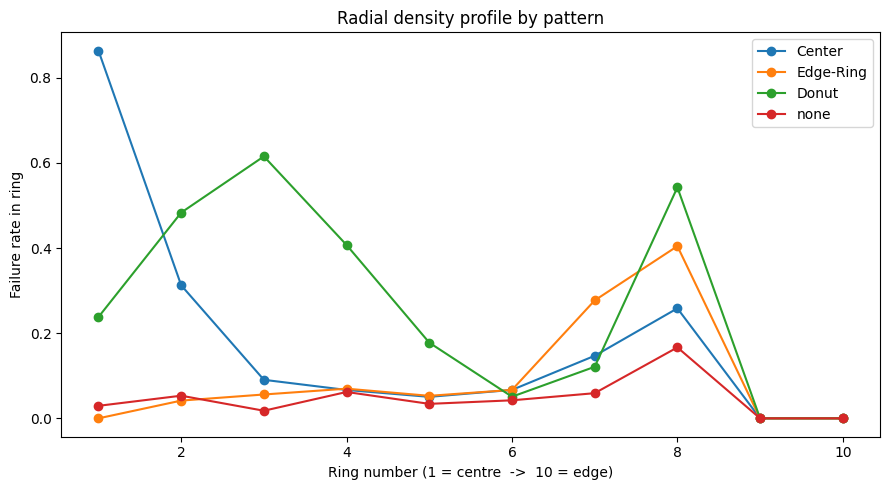

In [5]:
# ============================================================
# STAGE 2.4 — RADIAL DENSITY PROFILE (size-invariant hand feature)
# For each wafer:
#     1. Split it into concentric rings from the center to the edge
#     2. Measure the fraction of failed dies in each ring. 
# Captures the radial signature that separates Center / Edge-Ring / Donut / none.
# ============================================================

# The function below turns any wafer map, of any size, into a fixed-length vector of failure rates by radius.
#     1. Find the wafer's center,
#     2. Compute every die's distance from it,
#     3. normalize those distances to 0..1, so maps of different sizes line up, and 
#     4. Bin the dies into rings and take the failure fraction in each ring. 
# "Failure fraction" = failed dies divided by total dies present in that ring (comparable across wafer sizes).
def radial_density_profile(wmap, n_bins=10):
    # Coordinates of every pixel. rows/cols index the 2D map.
    rows, cols = np.indices(wmap.shape)          # two arrays giving the (row, col) of each pixel

    # Wafer centre = geometric middle of the grid.
    cr, cc = (wmap.shape[0] - 1) / 2, (wmap.shape[1] - 1) / 2   # centre row, centre col

    # Euclidean distance of every pixel from the centre.
    dist = np.sqrt((rows - cr) ** 2 + (cols - cc) ** 2)        # radius of each pixel

    # Normalise distances to 0..1 so ring boundaries are relative, not absolute.
    # This step makes the feature size-invariant.
    dist = dist / dist.max()                                    # farthest pixel becomes radius 1.0

    # A pixel is "on the wafer" if it's a die at all (value 1 or 2, not 0).
    on_wafer = wmap > 0                                         # boolean mask of real die positions
    failed   = wmap == 2                                        # boolean mask of failed dies

    profile = []                                               # will hold one failure-rate per ring
    edges = np.linspace(0, 1, n_bins + 1)                      # n_bins rings between radius 0 and 1
    for k in range(n_bins):                                    # walk outward ring by ring
        # Pixels whose normalised radius falls in this ring.
        in_ring = (dist >= edges[k]) & (dist < edges[k + 1])   # boolean mask for ring k
        total   = np.sum(in_ring & on_wafer)                   # dies present in this ring
        fails   = np.sum(in_ring & failed)                     # failed dies in this ring
        # Failure rate for the ring; guard against divide-by-zero on empty rings.
        profile.append(fails / total if total > 0 else 0.0)    # rate, or 0 if the ring has no dies
    return np.array(profile)                                   # fixed length = n_bins, any input size


# Quick visual check on one example per radial pattern.
# If the profiles look like the physical descriptions above (Center front-loaded, Edge-Ring back-
# loaded, Donut humped, none flat), the feature works and we can batch it.
test_classes = ['Center', 'Edge-Ring', 'Donut', 'none']
fig, ax = plt.subplots(figsize=(9, 5))
for cls in test_classes:                                       # one representative wafer per class
    wmap = work[work['label'] == cls].iloc[0]['waferMap']
    prof = radial_density_profile(wmap)
    ax.plot(range(1, 11), prof, marker='o', label=cls)         # x = ring number, y = failure rate

ax.set_xlabel('Ring number (1 = centre  ->  10 = edge)')
ax.set_ylabel('Failure rate in ring')
ax.set_title('Radial density profile by pattern')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# STAGE 2.5 — RADON-BASED LINEARITY FEATURES (for Scratch)
# A scratch = a thin line of failed dies. Density can't see it; collinearity can.
# The Radon transform integrates the failure map along straight lines at many angles — 
# collinear failures stack into a sharp peak, scattered ones don't. 
# We summarise that peak into a few numbers that a model can use.
# ============================================================
from skimage.transform import radon      # Radon transform: line-integral projections at many angles

# The function 
#       1. isolates just the failed dies (the only thing a scratch lives in),
#       2. runs the Radon transform to get its projections across 0–180 degrees,
#       3. summarises the result with a few scalars. 
# The most important is the ratio of the strongest projection value to the average — 
#       -- a tall, isolated peak (high ratio) means "a line exists at some angle";
#       -- a flat sinogram (low ratio) means "no linear structure". 
# We return a small set of such summary numbers rather than the whole sinogram, 
# so each wafer yields a fixed, compact feature vector regardless of its size.
def radon_features(wmap):
    # Keep only failed dies as a clean 0/1 image — the scratch signal.
    fail_img = (wmap == 2).astype(np.float64)          # 1 where a die failed, 0 elsewhere

    # A wafer with almost no failures can't contain a scratch; 
    # short-circuit to zeros so we don't feed noise (or crash) into the transform.
    if fail_img.sum() < 3:                              # fewer than 3 failed dies -> no line possible
        return np.array([0.0, 0.0, 0.0])

    # Project along lines at 0,1,2,...,179 degrees.
    theta = np.arange(0, 180, 1)                        # one projection per degree
    sino  = radon(fail_img, theta=theta, circle=False) # sinogram: rows=positions, cols=angles

    # Summarise the sinogram into a few size-independent scalars.
    peak      = sino.max()                              # strongest single line-integral anywhere
    mean_val  = sino.mean()                             # average projection strength
    peak_ratio = peak / mean_val if mean_val > 0 else 0.0   # tall isolated peak => a line exists

    # Which angle produced the strongest projection — i.e., the line's orientation.
    strongest_angle_strength = sino.max(axis=0).max()  # peak strength of the best angle
    return np.array([peak, peak_ratio, strongest_angle_strength])


# Sanity check: compare the peak_ratio across a class that HAS lines (Scratch) and two that don't (Random has scattered fails, none is near-empty).
# Scratch should show a clearly higher peak_ratio, confirming the feature responds to collinearity rather than to failure count.
for cls in ['Scratch', 'Random', 'none']:
    print(f"\n{cls}:")
    subset = work[work['label'] == cls].iloc[:5]        # first 5 wafers of the class
    for _, r in subset.iterrows():
        feats = radon_features(r.waferMap)
        print(f"   peak={feats[0]:7.1f}   peak_ratio={feats[1]:6.2f}   "
              f"n_fails={int((r.waferMap==2).sum())}")


Scratch:
   peak=   18.3   peak_ratio=  7.38   n_fails=206
   peak=   14.5   peak_ratio=  4.45   n_fails=121
   peak=   15.0   peak_ratio=  4.31   n_fails=129
   peak=   13.2   peak_ratio=  4.17   n_fails=117
   peak=   15.2   peak_ratio=  6.61   n_fails=85

Random:
   peak=   17.1   peak_ratio=  2.61   n_fails=242
   peak=   22.4   peak_ratio=  2.73   n_fails=304
   peak=   17.1   peak_ratio=  2.59   n_fails=244
   peak=   19.4   peak_ratio=  2.59   n_fails=277
   peak=   18.7   peak_ratio=  3.13   n_fails=221

none:
   peak=    6.0   peak_ratio=  4.62   n_fails=88
   peak=    7.6   peak_ratio=  6.04   n_fails=86
   peak=    5.3   peak_ratio=  5.48   n_fails=66
   peak=    6.9   peak_ratio=  4.52   n_fails=104
   peak=    6.1   peak_ratio=  5.85   n_fails=71


In [7]:
# ============================================================
# STAGE 2.6 — GEOMETRY FEATURES (angular coverage + connectivity)
# Two features targeting the pairs the earlier ones can't split:
#   angular coverage -> Edge-Ring (full wrap) vs Edge-Loc (arc)
#   connectivity     -> Near-full (one blob) vs Random (speckle)
# ============================================================
from scipy import ndimage                # ndimage.label groups touching pixels into components

# ANGULAR COVERAGE. 
#      1. Take the failed dies, 
#      2. Compute each one's angle around the wafer centre (like the hand-position on a clock), 
#      3. sort those angles, and
#      4. Find the largest empty gap between consecutive failures. 
# A full ring has no big gap (failures all the way round); 
# A localized arc leaves most of the circle empty, i.e., one large gap. 
# We report coverage as "fraction of the circle that is NOT the biggest gap" — 
# near 1.0 for a full ring, small for an arc — plus the raw spread, so the model gets the signal directly.

def angular_coverage(wmap):
    failed = (wmap == 2)                                   # boolean mask of failed dies
    if failed.sum() < 3:                                   # too few to define an angular spread
        return np.array([0.0, 0.0])

    rows, cols = np.where(failed)                          # coordinates of the failed dies
    cr, cc = (wmap.shape[0]-1)/2, (wmap.shape[1]-1)/2      # wafer centre
    angles = np.arctan2(rows - cr, cols - cc)             # angle of each failed die, -pi..pi
    angles = np.sort(angles)                               # sort so we can look at gaps between them

    # Gaps between consecutive angles, including the wrap-around from last back
    # to first (that's the +2*pi term), so a full circle is handled correctly.
    gaps = np.diff(angles)                                 # gaps between neighbours
    wrap_gap = (angles[0] + 2*np.pi) - angles[-1]          # gap across the -pi/+pi seam
    gaps = np.append(gaps, wrap_gap)

    largest_gap = gaps.max()                               # biggest empty arc
    coverage = 1.0 - (largest_gap / (2*np.pi))             # 1.0 = full wrap, small = narrow arc
    angular_std = np.std(angles)                            # raw spread of angles, a secondary cue
    return np.array([coverage, angular_std])


# CONNECTIVITY. 
#        1. Label the failed-die mask into connected components (blobs of touching failures),
#        2. summarise: how many blobs there are, and how big the largest one is relative to all failures. 
# One dominant blob covering most failures => contiguous (Near-full); 
# many blobs each tiny => scattered (Random).
# Both numbers are ratios/counts that don't depend on wafer size.
def connectivity_features(wmap):
    failed = (wmap == 2)                                   # boolean mask of failed dies
    total_fails = failed.sum()
    if total_fails < 1:                                    # nothing to measure
        return np.array([0.0, 0.0])

    labeled, n_components = ndimage.label(failed)          # group touching failed dies into blobs
    if n_components == 0:
        return np.array([0.0, 0.0])

    # Size of each blob, then the largest blob as a fraction of all failures.
    comp_sizes = np.bincount(labeled.ravel())[1:]          # [1:] drops the background (label 0)
    largest_frac = comp_sizes.max() / total_fails          # ~1.0 = one big blob, small = fragmented

    # Fragmentation: components per failed die. High = lots of separate specks.
    frag = n_components / total_fails                      # ~1.0 = every fail isolated (Random-like)
    return np.array([largest_frac, frag])


# Test both features on the pairs they target. 
# For angular coverage,
#       -- Edge-Ring near 1.0 and 
#       -- Edge-Loc clearly lower. 

# For connectivity,
#       -- Near-full to show a large largest_frac (one blob) and low fragmentation,
#       -- Random shows the opposite.
print("ANGULAR COVERAGE  (expect Edge-Ring ~1.0 full wrap, Edge-Loc lower arc):")
for cls in ['Edge-Ring', 'Edge-Loc']:
    print(f"  {cls}:")
    for _, r in work[work['label'] == cls].iloc[:5].iterrows():
        cov = angular_coverage(r.waferMap)
        print(f"     coverage={cov[0]:.2f}   angular_std={cov[1]:.2f}")

print("\nCONNECTIVITY  (expect Near-full: high largest_frac, low frag; Random: opposite):")
for cls in ['Near-full', 'Random']:
    print(f"  {cls}:")
    for _, r in work[work['label'] == cls].iloc[:5].iterrows():
        con = connectivity_features(r.waferMap)
        print(f"     largest_frac={con[0]:.2f}   fragmentation={con[1]:.2f}")

ANGULAR COVERAGE  (expect Edge-Ring ~1.0 full wrap, Edge-Loc lower arc):
  Edge-Ring:
     coverage=0.98   angular_std=1.70
     coverage=0.94   angular_std=1.63
     coverage=0.97   angular_std=1.74
     coverage=0.97   angular_std=1.78
     coverage=0.93   angular_std=1.70
  Edge-Loc:
     coverage=0.97   angular_std=1.67
     coverage=0.97   angular_std=1.68
     coverage=0.96   angular_std=1.60
     coverage=0.97   angular_std=1.53
     coverage=0.97   angular_std=1.56

CONNECTIVITY  (expect Near-full: high largest_frac, low frag; Random: opposite):
  Near-full:
     largest_frac=1.00   fragmentation=0.00
     largest_frac=0.97   fragmentation=0.02
     largest_frac=1.00   fragmentation=0.00
     largest_frac=1.00   fragmentation=0.00
     largest_frac=1.00   fragmentation=0.00
  Random:
     largest_frac=0.14   fragmentation=0.18
     largest_frac=0.82   fragmentation=0.08
     largest_frac=0.24   fragmentation=0.23
     largest_frac=0.30   fragmentation=0.14
     largest_frac=0.3

In [8]:
# ============================================================
# STAGE 2.6b — ANGULAR CONCENTRATION (corrected Edge-Ring vs Edge-Loc)
# The gap-based coverage feature failed: a few stray failures fill the "empty" arc,
# So Edge-Loc reads as fully-wrapped as Edge-Ring.
# Fix: bin the failure angles into a histogram and measure how
# PEAKED it is. 
# Edge-Loc concentrates in a few bins; 
# Edge-Ring spreads evenly.
# A histogram dilutes strays instead of being defeated by them.
# ============================================================

#     1. Take the failed dies' angles
#     2. Drop them into an N-bin histogram around the
# full circle, 
#     3. normalize it to a distribution, and 
#     4. Summarise its peakedness in two ways: 
#               -- the height of the fullest bin (one dominant sector => high) and 
#               -- the fraction of bins that have essentially no failures (an arc leaves most bins empty => high; a full ring fills every bin => near zero). 
# Both are size-invariant because they're computed on normalized angle counts, not raw dies.
def angular_concentration(wmap, n_bins=12):
    failed = (wmap == 2)                                  # failed-die mask
    if failed.sum() < 3:                                  # too few to form a distribution
        return np.array([0.0, 0.0])

    rows, cols = np.where(failed)                         # failed-die coordinates
    cr, cc = (wmap.shape[0]-1)/2, (wmap.shape[1]-1)/2     # wafer centre
    angles = np.arctan2(rows - cr, cols - cc)            # angle of each failed die

    # Histogram the angles into n_bins sectors around the circle, then turn
    # counts into fractions so the measure doesn't depend on how many failures.
    hist, _ = np.histogram(angles, bins=n_bins, range=(-np.pi, np.pi))
    hist = hist / hist.sum()                              # normalise to a distribution

    peak_bin_height = hist.max()                          # tallest sector: high => concentrated arc
    empty_bin_frac  = np.mean(hist < 0.01)                # share of near-empty sectors: high => arc
    return np.array([peak_bin_height, empty_bin_frac])


# Re-test on the same pair. 
# Now we expect a real gap: 
#          -- Edge-Loc should show a tall peak bin and many empty bins (arc), 
#          -- Edge-Ring shows a low, even peak and few empty bins (full wrap).
print("ANGULAR CONCENTRATION  (expect Edge-Loc: high peak + many empty bins; Edge-Ring: low + few):")
for cls in ['Edge-Ring', 'Edge-Loc']:
    print(f"  {cls}:")
    for _, r in work[work['label'] == cls].iloc[:6].iterrows():
        ac = angular_concentration(r.waferMap)
        print(f"     peak_bin={ac[0]:.2f}   empty_bin_frac={ac[1]:.2f}")

ANGULAR CONCENTRATION  (expect Edge-Loc: high peak + many empty bins; Edge-Ring: low + few):
  Edge-Ring:
     peak_bin=0.17   empty_bin_frac=0.00
     peak_bin=0.13   empty_bin_frac=0.00
     peak_bin=0.12   empty_bin_frac=0.00
     peak_bin=0.13   empty_bin_frac=0.00
     peak_bin=0.16   empty_bin_frac=0.00
     peak_bin=0.16   empty_bin_frac=0.08
  Edge-Loc:
     peak_bin=0.20   empty_bin_frac=0.00
     peak_bin=0.24   empty_bin_frac=0.00
     peak_bin=0.27   empty_bin_frac=0.00
     peak_bin=0.22   empty_bin_frac=0.00
     peak_bin=0.27   empty_bin_frac=0.00
     peak_bin=0.26   empty_bin_frac=0.00


In [9]:
# ============================================================
# STAGE 2.7 — BATCH FEATURE EXTRACTION (classical route)
# Runs all four hand-feature functions over every wafer and
# assembles one (N, 16) feature table with named columns, in the
# SAME row order as X_img and y. This is the interpretable route
# counterpart to the CNN image tensor from 2.3.
#
# The Radon transform dominates the cost, so it is computed on a
# small fixed 48x48 grid and at 3-degree angle steps. Radon cost
# scales with pixel count and angle count, so cutting both keeps the
# job to minutes. Neither reduction affects the peak / peak_ratio
# signal we extract: a line stays a clear line at 48x48, and 3-degree
# steps still resolve its orientation well within what we need.
# ============================================================
import time
import pandas as pd
from skimage.transform import radon, resize

# The Radon feature extractor. It isolates the failed dies (the only place a
# scratch lives), shrinks that mask to a fixed 48x48 grid so every wafer costs
# the same and the transform stays cheap, then projects the image along lines
# at 3-degree steps from 0 to 180. Collinear failures stack into a tall peak in
# the sinogram; scattered ones don't. We summarise the sinogram into three
# scalars — the peak height, the peak-to-mean ratio (a tall isolated peak means
# "a line exists"), and the strength of the best angle — so each wafer yields a
# fixed, size-independent feature vector.
def radon_features_fast(wmap):
    fail_img = (wmap == 2).astype(np.float64)             # 1 where a die failed, 0 elsewhere
    if fail_img.sum() < 3:                                # fewer than 3 failures -> no line possible
        return np.array([0.0, 0.0, 0.0])

    small = resize(fail_img, (48, 48), order=0,           # fixed small grid; nearest keeps dies crisp
                   preserve_range=True, anti_aliasing=False)

    theta = np.arange(0, 180, 3)                          # projection angles, every 3 degrees
    sino  = radon(small, theta=theta, circle=False)       # sinogram: rows=positions, cols=angles

    peak       = sino.max()                               # strongest single line-integral anywhere
    mean_val   = sino.mean()                              # average projection strength
    peak_ratio = peak / mean_val if mean_val > 0 else 0.0 # tall isolated peak => a line is present
    strongest_angle_strength = sino.max(axis=0).max()     # peak strength of the best-aligned angle
    return np.array([peak, peak_ratio, strongest_angle_strength])


# The batch loop. 
# For each wafer we call all four feature functions and concatenate their outputs into one 16-number row.
# angular_concentration returns two values but only its first (peak_bin) carries usable signal, 
# so we take index 0. 
# We collect rows in a list and build the DataFrame once at the end, which is far faster than growing a table row by row. 
# Progress prints every 20,000 wafers so it's clear the kernel is working.
feature_rows = []                                         # one 16-value list per wafer
start = time.time()
for i, row in enumerate(work.itertuples(index=False)):    # itertuples = fast row iteration
    wmap = row.waferMap
    rad  = radial_density_profile(wmap)                   # 10 values: failure rate per radial ring
    rdn  = radon_features_fast(wmap)                      # 3 values: peak, peak_ratio, angle-strength
    con  = connectivity_features(wmap)                    # 2 values: largest_frac, fragmentation
    ang  = angular_concentration(wmap)[0]                 # 1 value: angular peak_bin
    feature_rows.append(list(rad) + list(rdn) + list(con) + [ang])
    if (i + 1) % 20000 == 0:
        print(f"  {i+1:,} / {len(work):,} done   ({time.time()-start:.0f}s elapsed)")

# Explicit, human-readable column names in the exact order the values were appended above.
# These names are what make Stage 4's feature-importance output readable — 'radon_peak_ratio' tells a story, 'feature_11' does not.
feature_names = (
    [f'radial_ring_{k}' for k in range(1, 11)] +          # radial_ring_1 ... radial_ring_10
    ['radon_peak', 'radon_peak_ratio', 'radon_angle_strength'] +
    ['conn_largest_frac', 'conn_fragmentation'] +
    ['angular_peak_bin']
)

# Assemble the table. Its row order matches work, and therefore X_img and y.
X_feat = pd.DataFrame(feature_rows, columns=feature_names)

print(f"\nDone in {time.time()-start:.0f}s")
print("X_feat shape:", X_feat.shape)                      # expect (172950, 16)
print("\nFirst 3 rows:")
print(X_feat.head(3))
print("\nAny NaNs?", X_feat.isna().sum().sum())            # must be 0 — sklearn rejects NaNs

# ALIGNMENT CHECK — feature table, image tensor, and labels must all agree in
# row count. If any drifted out of order, stop here rather than let silently
# wrong metrics reach Stage 4.
assert len(X_feat) == X_img.shape[0] == len(y), "Row-count mismatch across X_feat / X_img / y!"
print("\nAlignment OK — X_feat, X_img, y all have", len(X_feat), "rows.")

  20,000 / 172,950 done   (122s elapsed)
  40,000 / 172,950 done   (243s elapsed)
  60,000 / 172,950 done   (364s elapsed)
  80,000 / 172,950 done   (483s elapsed)
  100,000 / 172,950 done   (603s elapsed)
  120,000 / 172,950 done   (725s elapsed)
  140,000 / 172,950 done   (846s elapsed)
  160,000 / 172,950 done   (966s elapsed)

Done in 1045s
X_feat shape: (172950, 16)

First 3 rows:
   radial_ring_1  radial_ring_2  radial_ring_3  radial_ring_4  radial_ring_5  \
0       0.029412       0.053191       0.017857       0.061947       0.034014   
1       0.029412       0.053191       0.023810       0.039823       0.034014   
2       0.000000       0.031915       0.017857       0.022124       0.006803   

   radial_ring_6  radial_ring_7  radial_ring_8  radial_ring_9  radial_ring_10  \
0       0.042373       0.059102       0.166667            0.0             0.0   
1       0.031073       0.052009       0.266667            0.0             0.0   
2       0.019774       0.075650       0.155556 

In [10]:
# ============================================================
# STAGE 2.8 — SAVE ARTIFACTS FOR STAGE 3
# Persist the three aligned objects so Stage 3 loads them in seconds instead of recomputing: 
#         the CNN image tensor,
#         the classical feature table
#         the shared label array. 
# Saving as .npy / .pkl keeps exact dtypes and structure.
# ============================================================

# np.save writes a single array to a fast binary .npy. Used for the image tensor and the labels. 
# The feature table is a pandas DataFrame, so it goes to pickle to preserve the column names. 
# All three land in /kaggle/working, which is what a committed notebook version persists as its output.
np.save('/kaggle/working/X_img.npy', X_img)          # (172950, 64, 64) uint8 image cube
np.save('/kaggle/working/y.npy', y)                  # (172950,) labels, shared by both routes
X_feat.to_pickle('/kaggle/working/X_feat.pkl')       # (172950, 16) named feature table

# Read the file sizes back so we can confirm they actually wrote.
import os
for f in ['X_img.npy', 'y.npy', 'X_feat.pkl']:
    mb = os.path.getsize(f'/kaggle/working/{f}') / 1024**2
    print(f"{f:15s} {mb:8.1f} MB")

print("\nSaved. Ready for Stage 3.")

X_img.npy          675.6 MB
y.npy                5.9 MB
X_feat.pkl          21.1 MB

Saved. Ready for Stage 3.
